## PRESENTACIÓN DEL PROYECTO

### Abstracto: Motivación y Audiencia

La industria de los videojuegos representa uno de los mercados de entretenimiento más grandes y dinámicos a nivel global, con millones de consumidores y una constante evolución en términos de plataformas, géneros y modelos de negocio. Comprender qué factores influyen en el éxito comercial de un videojuego resulta fundamental tanto para desarrolladores como para publishers y analistas de mercado.

La motivación de este proyecto surge de la necesidad de analizar, a partir de datos reales, cómo variables como el género del videojuego, la plataforma de lanzamiento y las valoraciones de críticos impactan en las ventas globales. A través de un análisis exploratorio de datos, se busca identificar patrones relevantes que permitan comprender mejor el comportamiento del mercado.

La audiencia a la que está dirigido este proyecto incluye analistas de datos, equipos de marketing, desarrolladores de videojuegos y empresas editoras interesadas en tomar decisiones basadas en datos para optimizar lanzamientos y estrategias comerciales.

### Contexto Comercial y Analítico

Desde una perspectiva comercial, este proyecto se enmarca en el mercado global de videojuegos, donde la competencia entre plataformas y géneros es elevada y el éxito de un título depende de múltiples factores. Contar con información analizada de forma sistemática permite reducir la incertidumbre asociada a decisiones estratégicas como la elección de plataforma o género.

Desde el punto de vista analítico, el proyecto contempla una primera etapa de análisis exploratorio de datos (EDA), orientada a comprender la estructura del dataset, detectar patrones, valores atípicos y relaciones entre variables. En una etapa posterior del proyecto, se prevé el desarrollo de un modelo de machine learning que permita predecir ventas globales o clasificar videojuegos según su desempeño comercial.

### Preguntas e Hipótesis

**Preguntas de interés:**
- ¿Existen diferencias significativas en las ventas globales según el género del videojuego?
- ¿La plataforma de lanzamiento influye en el nivel de ventas?
- ¿Existe una relación entre las valoraciones de los críticos y las ventas globales?

**Hipótesis:**
- Los videojuegos pertenecientes a ciertos géneros presentan mayores ventas globales.
- Las plataformas más populares concentran mayores niveles de ventas.
- A mayores puntuaciones de los críticos, mayores ventas globales, aunque esta relación puede variar según el género.

### Objetivo del Proyecto

El objetivo principal del proyecto es realizar un análisis exploratorio de datos que permita identificar los factores que influyen en las ventas globales de videojuegos. Como objetivo final, se busca desarrollar un modelo de machine learning de tipo regresión o clasificación que permita estimar el desempeño comercial de un videojuego a partir de sus características.

## LECTURA DE DATOS

### Librerías y configuración

In [2]:
# [REQUISITO - LIBRERIAS] Importacion de librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Lectura del dataset

In [3]:
import pandas as pd

# Subir el archivo CSV manualmente a Colab:
#   1. Panel izquierdo (icono de carpeta)
#   2. Arrastrar el archivo Video_Games_Sales_with_Ratings.csv
#   3. El archivo queda en /content/ (mismo nivel que sample_data)
#
# Alternativa por codigo:
#   from google.colab import files
#   files.upload()   # abre el selector de archivos del navegador
#
df = pd.read_csv("/content/Video_Games_Sales_with_Ratings.csv")
df.head()

Mounted at /content/drive


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### Análisis inicial

In [4]:
# [REQUISITO - EDA] Dimensiones del dataset
df.shape

(16719, 16)

El dataset utilizado contiene más de 2000 registros y más de 15 variables, cumpliendo con los requisitos del proyecto final.

In [5]:
# [REQUISITO - EDA] Tipos de datos y estadisticos descriptivos
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


### Descripción de variables

- **Name**: nombre del videojuego  
- **Platform**: plataforma de lanzamiento  
- **Year_of_Release**: año de lanzamiento  
- **Genre**: género del videojuego  
- **Publisher**: empresa publicadora
- **NA_Sales**: Ventas en América del Norte (millones).
- **EU_Sales**: Ventas en Europa (millones).
- **JP_Sales**: Ventas en Japón (millones).
- **Other_Sales**: Ventas en otros mercados.  
- **Global_Sales**: ventas globales (millones de unidades)  
- **Critic_Score**: puntaje otorgado por críticos  
- **Critic_Count**: Cantidad de críticas profesionales registradas.
- **User_Score**: puntaje otorgado por usuarios
- **User_Count**: Cantidad de valoraciones de usuarios.
- **Developer**: Empresa desarrolladora del videojuego.
- **Rating**: Clasificación por edades del videojuego.


## DATA WRANGLING

### Duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

### Valores nulos

In [7]:
# [REQUISITO - EDA] Conteo de valores nulos por columna
df.isna().sum()

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


**Tratamiento de valores nulos**

Se realiza una nueva revisión de valores nulos para poder continuar con la etapa de modelado. En la primera parte del proyecto solo se identificaron, mientras que en esta etapa se procederá a imputarlos para evitar errores al entrenar modelos de machine learning.

In [13]:
# Convertir User Score a número
df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")

Se transformó la variable a formato numérico para poder utilizarla correctamente en los modelos de machine learning.

In [102]:
# [REQUISITO - PREPROCESADO] Imputacion de valores nulos
# Relleno de variables numéricas
df["Critic_Score"] = df["Critic_Score"].fillna(df["Critic_Score"].mean())
df["User_Score"] = df["User_Score"].fillna(df["User_Score"].mean())
df["Critic_Count"] = df["Critic_Count"].fillna(df["Critic_Count"].median())
df["User_Count"] = df["User_Count"].fillna(df["User_Count"].median())
df["Year_of_Release"] = df["Year_of_Release"].fillna(df["Year_of_Release"].median())
# Relleno de variables categóricas
df["Rating"] = df["Rating"].fillna(df["Rating"].mode()[0])
df["Developer"] = df["Developer"].fillna("Unknown")
df["Genre"] = df["Genre"].fillna(df["Genre"].mode()[0])
df["Publisher"] = df["Publisher"].fillna(df["Publisher"].mode()[0])

Se reemplazaron los valores faltantes utilizando:
- Media para variables numéricas con distribución aproximadamente normal
- Mediana para variables con posibles outliers
- Moda para variables categóricas

Se evitó el uso del parámetro inplace debido a futuras modificaciones en pandas que podrían afectar su funcionamiento.

### Outliers

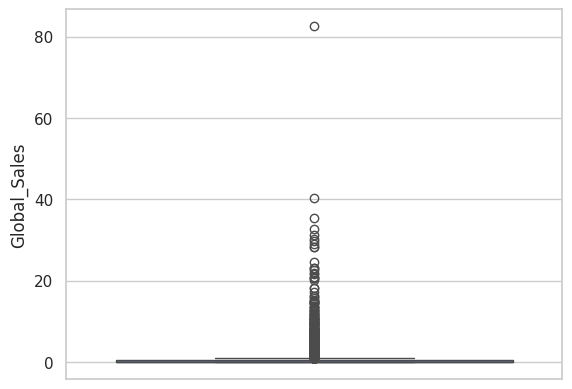

In [ ]:
# Boxplot de ventas

sns.boxplot(y=df["Global_Sales"])
plt.show()

# A partir del boxplot se observa la presencia de valores atípicos en las ventas globales. Esto indica que existen videojuegos con ventas considerablemente superiores al promedio, lo cual es esperable en este mercado donde pocos títulos concentran gran parte del éxito comercial.

### Transformaciones

In [ ]:
# Convertir año a número

df["Year_of_Release"] = pd.to_numeric(df["Year_of_Release"], errors="coerce")

In [16]:
# Eliminar espacios en nombres de columnas

df.columns = df.columns.str.strip()

### EDA

### Univariado

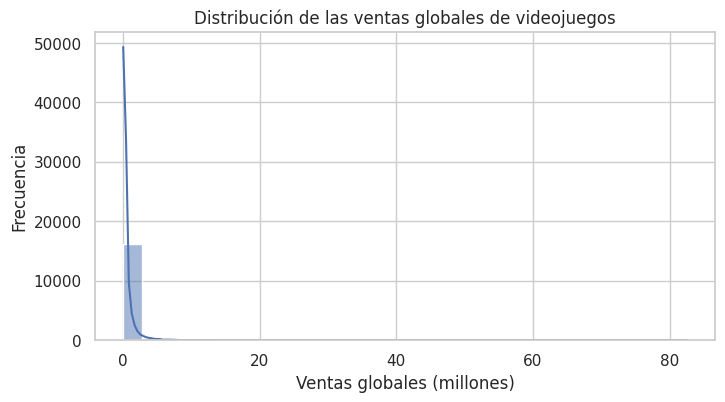

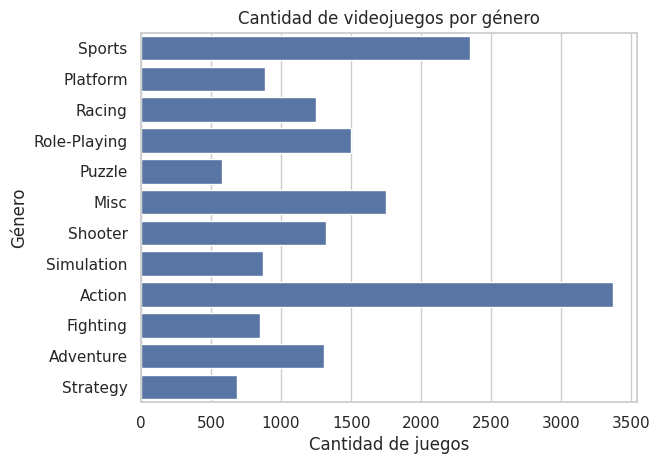

In [ ]:
# [REQUISITO - EDA - UNIVARIADO] Distribucion de la variable objetivo y conteo por categoria
# Histograma de ventas globales

plt.figure(figsize=(8,4))
sns.histplot(df["Global_Sales"], bins=30, kde=True)
plt.title("Distribución de las ventas globales de videojuegos")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("Frecuencia")
plt.show()

# La distribución de las ventas globales presenta una fuerte asimetría positiva. La mayoría de los videojuegos registra ventas bajas o moderadas, mientras que un número reducido alcanza ventas muy elevadas.

# Conteo por género

sns.countplot(y=df["Genre"])
plt.title("Cantidad de videojuegos por género")
plt.xlabel("Cantidad de juegos")
plt.ylabel("Género")
plt.show()

# El gráfico muestra que algunos géneros cuentan con una mayor cantidad de títulos lanzados, lo que sugiere una mayor oferta en esos segmentos del mercado.

## Bivariado

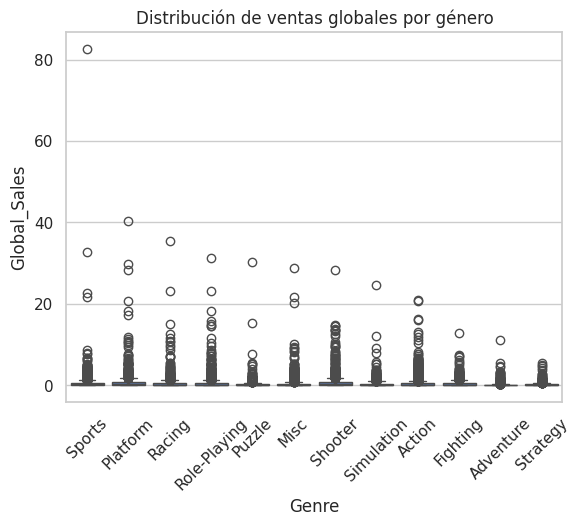

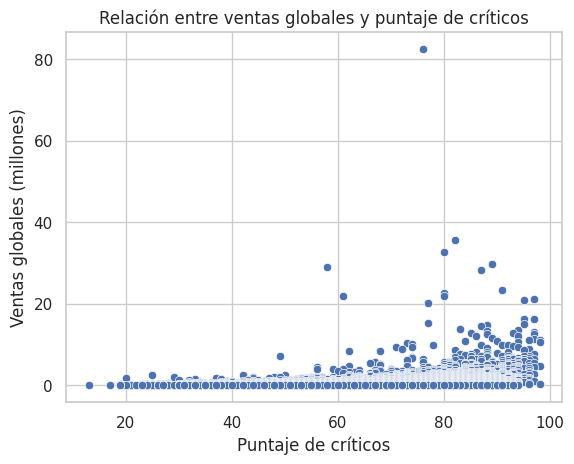

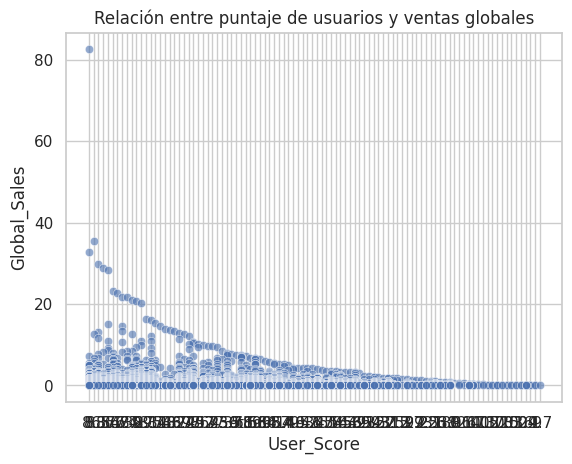

In [ ]:
# [REQUISITO - EDA - BIVARIADO] Relacion entre variables numericas y la variable objetivo
# Ventas por género

sns.boxplot(x="Genre", y="Global_Sales", data=df)
plt.xticks(rotation=45)
plt.title("Distribución de ventas globales por género")
plt.show()

# Se observan diferencias en las ventas globales entre los distintos géneros. Algunos géneros presentan medianas de ventas más altas y una mayor dispersión, lo que indica un mayor potencial comercial.

# Puntaje de críticos vs ventas

sns.scatterplot(
    x="Critic_Score",
    y="Global_Sales",
    data=df
)
plt.title("Relación entre ventas globales y puntaje de críticos")
plt.xlabel("Puntaje de críticos")
plt.ylabel("Ventas globales (millones)")
plt.show()

# El gráfico sugiere una relación positiva moderada entre el puntaje otorgado por los críticos y las ventas globales. Sin embargo, la dispersión de los puntos indica que el puntaje no es el único factor determinante del éxito comercial.

# Ventas por plataforma

sns.scatterplot(x="User_Score", y="Global_Sales", data=df, alpha=0.6)
plt.title("Relación entre puntaje de usuarios y ventas globales")
plt.show()

# En este gráfico se analiza la relación entre la valoración de los usuarios y las ventas globales. Se observa una dispersión elevada, con algunos títulos que logran altas ventas incluso con puntajes moderados. Esto sugiere que la percepción del público tiene impacto en las ventas, aunque nuevamente no resulta un factor decisivo por sí solo.

## Multivariado

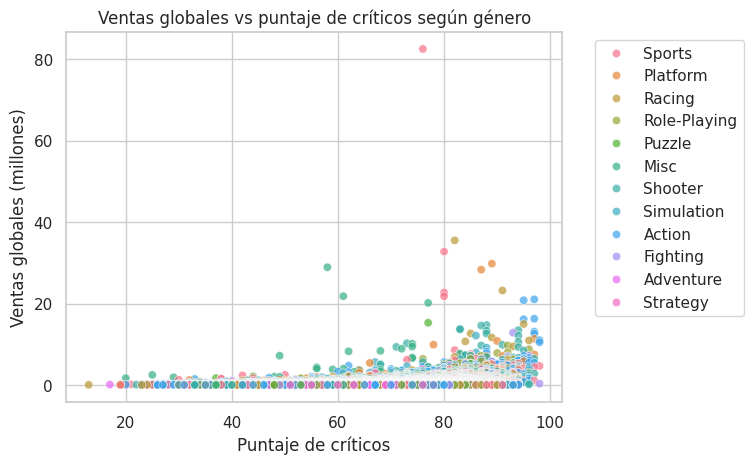

In [ ]:
# [REQUISITO - EDA - MULTIVARIADO] Analisis multivariado con hue
sns.scatterplot(
    data=df,
    x="Critic_Score",
    y="Global_Sales",
    hue="Genre",
    alpha=0.7
)
plt.title("Ventas globales vs puntaje de críticos según género")
plt.xlabel("Puntaje de críticos")
plt.ylabel("Ventas globales (millones)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Este análisis multivariado permite observar que la relación entre las ventas globales y el puntaje de los críticos varía según el género del videojuego. Algunos géneros logran altos niveles de ventas aun con puntuaciones moderadas, mientras que en otros la valoración parece tener un mayor impacto.

### Conclusiones del EDA

El análisis exploratorio evidencia que las ventas globales se concentran en un número reducido de videojuegos. Se observan diferencias significativas entre géneros y plataformas, así como una relación moderada entre las valoraciones de los críticos y las ventas, que no se mantiene uniforme en todos los casos.

# **Preprocesamiento de datos**

**Codificación de variables categóricas**

In [81]:
# [NOTA] Codificacion de categoricas con LabelEncoder
# En la evaluacion final se requiere OneHotEncoder (para categoricas nominales)
# y TargetEncoder (para categoricas de alta cardinalidad)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Platform"] = le.fit_transform(df["Platform"])
df["Genre"] = le.fit_transform(df["Genre"])
df["Publisher"] = le.fit_transform(df["Publisher"])
df["Rating"] = le.fit_transform(df["Rating"])

**Escalado de variables numéricas**

In [82]:
# [REQUISITO - PREPROCESADO] Escalado de variables numericas con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    "Critic_Score",
    "User_Score",
    "Critic_Count",
    "User_Count",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

#**Feature Selection**

**Selección de variable objetivo y variables independientes**

In [89]:
# NOTA: La variable objetivo es Global_Sales (regresion continua)
# La evaluacion final requiere clasificacion binaria.
# Ver seccion 'CLASIFICACION BINARIA' al final del notebook.
X = df[["Critic_Score", "User_Score", "Year_of_Release"]]
y = df["Global_Sales"]

Se seleccionó como variable objetivo "Global_Sales", ya que representa el rendimiento comercial del videojuego. Como variables predictoras se eligieron el puntaje de críticos, el puntaje de usuarios y el año de lanzamiento.

# **Modelado**

**Librerias necesarias para implementar los modelos**

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**División de datos en conjuntos de entrenamiento y prueba**

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

**Predicción con conjunto de prueba**

Modelo 1 - Linear Regression

In [92]:
# [MODELO REGRESION 1] Linear Regression - predice ventas continuas
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

**Evaluación del rendimiento del modelo**

Métricas

In [96]:
# [METRICAS REGRESION] RMSE, MAE, R2 - metricas de regresion
print("Linear Regression")
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
RMSE: 1.756405257524452
MAE: 0.5997360702035002
R2: 0.0256887083563494


Modelo 2 - Decision Tree

In [97]:
# [MODELO REGRESION 2] Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

Métricas

In [98]:
# [METRICAS REGRESION] RMSE, MAE, R2
print("Decision Tree")
print("RMSE:", mean_squared_error(y_test, y_pred_dt) ** 0.5)
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree
RMSE: 1.9321890543605034
MAE: 0.5992094816371395
R2: -0.17909151478084628


Modelo 3 - Random Forest

In [99]:
# [MODELO REGRESION 3] Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

Métricas

In [100]:
# [METRICAS REGRESION] RMSE, MAE, R2
print("Random Forest")
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
RMSE: 1.7720345808822024
MAE: 0.5352233147038438
R2: 0.008271795765287138


**Conclusión sobre el modelado y las metricas**

Se evaluaron tres modelos de regresión: Linear Regression, Decision Tree y Random Forest.

Los resultados muestran que:

- Linear Regression obtuvo el mejor desempeño en términos de R² y RMSE.
- Random Forest presentó el menor error absoluto medio (MAE), aunque sin mejorar significativamente el R².
- Decision Tree mostró un rendimiento inferior, con un R² negativo, indicando que predice peor que la media.

En general, los valores de R² cercanos a cero sugieren que las variables seleccionadas no logran explicar adecuadamente la variabilidad de las ventas globales.

Esto indica que el problema es complejo y que podrían requerirse más variables o un mayor trabajo de feature engineering para mejorar el desempeño de los modelos.

Se concluye que el modelo de regresión lineal resulta el más adecuado dentro de los evaluados, debido a su mayor capacidad explicativa relativa, aunque el desempeño general es limitado.

# **Conclusiones Finales**

En este proyecto se realizó un análisis exploratorio de un dataset de ventas de videojuegos con el objetivo de comprender los factores que influyen en el éxito comercial de los títulos.

En la primera etapa se llevó a cabo un análisis exploratorio de datos (EDA), que permitió identificar patrones relevantes entre variables como el género, la plataforma, el puntaje de críticos y las ventas globales. Se observaron distribuciones asimétricas en las ventas y una alta dispersión, lo que sugiere que pocos títulos concentran gran parte del mercado.

En la segunda etapa se realizó el preprocesamiento de los datos, incluyendo:
- tratamiento de valores nulos mediante imputación (media, mediana y moda)
- conversión de variables a formatos adecuados
- codificación de variables categóricas
- normalización de variables numéricas

Posteriormente, se entrenaron tres modelos de regresión:
- Linear Regression
- Decision Tree
- Random Forest

Al evaluar el desempeño mediante métricas como RMSE, MAE y R², se observó que:

- Linear Regression presentó el mejor desempeño general, con el mayor valor de R² y menor RMSE.
- Random Forest logró el menor MAE, aunque sin una mejora significativa en la capacidad explicativa del modelo.
- Decision Tree obtuvo un rendimiento inferior, incluso con un R² negativo, indicando baja capacidad predictiva.

En términos generales, todos los modelos presentaron valores de R² cercanos a cero, lo que indica que las variables seleccionadas no logran explicar adecuadamente la variabilidad de las ventas globales.

Esto sugiere que el problema es complejo y que el desempeño del modelo podría mejorar incorporando nuevas variables, realizando un mayor trabajo de feature engineering o utilizando técnicas más avanzadas.

Finalmente, se concluye que, dentro de los modelos evaluados, la regresión lineal resulta la opción más consistente para este conjunto de datos, aunque con limitaciones en su capacidad predictiva.

Como línea futura de trabajo, se podrían explorar técnicas de selección de variables más avanzadas y modelos más complejos para mejorar la capacidad predictiva.

---
# [REQUISITO] CLASIFICACION BINARIA — Exito Comercial de Videojuegos

## ¿Por que agregamos esta seccion?

La parte anterior del notebook resuelve un problema de **regresion**:
predecir el numero exacto de ventas globales (un valor continuo como 3.5 millones).

La **evaluacion final** requiere **clasificacion binaria** (variable objetivo 0 o 1).
Esta seccion convierte el mismo dataset en un problema de clasificacion:

> **¿Fue este videojuego un exito comercial?**
> - Clase 1 (Exito): `Global_Sales > 1.0 millon` de unidades
> - Clase 0 (No exitoso): `Global_Sales <= 1.0 millon`

### ¿Por que 1.0 millon como umbral?

| Umbral | Razonamiento |
|---|---|
| **1.0M** (elegido) | Un juego que vende mas de 1 millon es considerado exitoso en la industria. Representa aprox. el top 25% del dataset. |
| 0.5M | Demasiado permisivo — muchos juegos medianos quedarian como "exitosos" |
| 5.0M | Demasiado restrictivo — solo blockbusters, pocas muestras de clase 1 |

Este umbral es una **decision de negocio**, no una decision estadistica.
En un proyecto real, este umbral lo definiria el equipo junto con expertos del dominio.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO - LIBRERIAS] Imports para la seccion de clasificacion
# ══════════════════════════════════════════════════════════════════
#
# Se importan librerias especificas de clasificacion binaria:
#   - missingno: visualizacion de nulos (EDA)
#   - Pipeline + ColumnTransformer: preprocesado sin data leakage
#   - SimpleImputer: imputa nulos (mediana para numericas, moda para categoricas)
#   - StandardScaler: normaliza variables numericas (requiere LogisticRegression)
#   - OneHotEncoder: convierte categorias en columnas 0/1
#   - LogisticRegression: modelo BASELINE (siempre el punto de comparacion)
#   - RandomForestClassifier: modelo principal (mas potente, no sensible a escala)
#   - StratifiedKFold: cross-validation con balance de clases garantizado
#   - GridSearchCV: busqueda sistematica de mejores hiperparametros
#   - roc_auc_score: metrica principal (ignora el desbalance de clases)
#   - classification_report: precision, recall, f1-score por clase
#   - confusion_matrix: las 4 combinaciones posibles de prediccion vs realidad
#   - roc_curve + auc: para graficar la curva ROC
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

# Recargar el dataset desde cero (sin las transformaciones de regresion anteriores)
# La carga limpia garantiza que no heredamos el LabelEncoder ni el StandardScaler anterior
df_clf = pd.read_csv("/content/Video_Games_Sales_with_Ratings.csv")
df_clf["User_Score"]       = pd.to_numeric(df_clf["User_Score"], errors="coerce")
df_clf["Year_of_Release"]  = pd.to_numeric(df_clf["Year_of_Release"], errors="coerce")
print(f"Dataset recargado: {df_clf.shape[0]:,} videojuegos, {df_clf.shape[1]} variables")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO - EDA] VISUALIZACION DE MISSINGNESS CON MISSINGNO
# ══════════════════════════════════════════════════════════════════
#
# En el dataset de videojuegos hay variables con muchos nulos:
#   Critic_Score / Critic_Count → ~50% de nulos (muchos juegos no tienen resenas de criticos)
#   User_Score / User_Count     → ~45% de nulos (idem usuarios)
#   Developer / Rating          → ~40% de nulos
#
# Pregunta clave: ¿los nulos de Critic_Score y User_Score son MCAR o MNAR?
#   Hipotesis MNAR: los juegos mas viejos (antes de Metacritic, ~2000) no tienen puntuacion
#   Si esto es cierto → imputar con "sin puntuacion" es valido (no falsea la distribucion)
#
# msno.matrix(): permite ver si los nulos de Critic_Score y User_Score aparecen juntos
#   Si las columnas blancas se alinean en las mismas filas → esos son los juegos sin resena
#   Si no se alinean → los nulos son independientes (MCAR)
#
# msno.bar(): muestra el % de completitud de cada variable de un vistazo
#
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(df_clf, ax=axes[0], sparkline=False, color=(0.27, 0.52, 0.71))
axes[0].set_title(
    "Patron de nulos por fila (msno.matrix)\n"
    "Negro = dato  |  Blanco = nulo  |  Alineacion = patron sistematico", fontsize=10)

msno.bar(df_clf, ax=axes[1], color=(0.27, 0.52, 0.71), fontsize=8)
axes[1].set_title(
    "Completitud por columna (msno.bar)\n"
    "Las barras cortas son las variables con mas nulos", fontsize=10)

plt.suptitle("[REQUISITO] Missingness — Video Games Sales Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen con decision de imputacion para cada variable
nulos_pct = df_clf.isnull().mean() * 100
print("Porcentaje de nulos y estrategia de imputacion:")
for col in df_clf.columns:
    pct_val = nulos_pct[col]
    if pct_val > 40:
        estrategia = "imputar con mediana (numerica) o moda (categorica)"
    elif pct_val > 0:
        estrategia = "imputar con mediana o moda"
    else:
        estrategia = "completa, sin imputacion"
    if pct_val > 0:
        print(f"  {col:<20}: {pct_val:5.1f}% nulos → {estrategia}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO - TARGET] Definicion de la Variable Objetivo Binaria
# ══════════════════════════════════════════════════════════════════
#
# Conversion de regresion → clasificacion binaria:
#   ANTES: predecir Global_Sales (numero continuo, ej: 3.2 millones)
#   AHORA: predecir si un juego supera 1 millon de ventas (0 o 1)
#
# Umbral elegido: 1.0 millon de unidades
#   Justificacion tecnica: percentil ~75 del dataset → mantiene clases razonablemente balanceadas
#   Justificacion de negocio: 1M de copias es el umbral de "exito" en la industria AAA
#
# Equivalente a problemas de churn:
#   Churn         : 0 = cliente sigue activo | 1 = cliente se fue
#   Exito de juego: 0 = ventas bajas/medias  | 1 = ventas altas (exito)
#
UMBRAL_EXITO = 1.0  # millones de unidades — decision de negocio
df_clf['EXITO_COMERCIAL'] = (df_clf['Global_Sales'] > UMBRAL_EXITO).astype(int)

conteo = df_clf['EXITO_COMERCIAL'].value_counts()
pct    = df_clf['EXITO_COMERCIAL'].value_counts(normalize=True) * 100

print(f"Umbral de exito: {UMBRAL_EXITO} millones de unidades vendidas globalmente")
print()
print(f"Clase 0 (ventas <= {UMBRAL_EXITO}M, no exitoso): {conteo.get(0,0):,} juegos ({pct.get(0,0):.1f}%)")
print(f"Clase 1 (ventas >  {UMBRAL_EXITO}M, exitoso):    {conteo.get(1,0):,} juegos ({pct.get(1,0):.1f}%)")
print()
print("Ejemplos de Clase 1 (exito comercial):")
print(df_clf[df_clf['EXITO_COMERCIAL'] == 1][['Name', 'Global_Sales', 'Genre', 'Platform']].head(5).to_string(index=False))
print()
print("Ejemplos de Clase 0 (sin exito comercial):")
print(df_clf[df_clf['EXITO_COMERCIAL'] == 0][['Name', 'Global_Sales', 'Genre', 'Platform']].head(5).to_string(index=False))

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO - EDA] BALANCE DE CLASES
# ══════════════════════════════════════════════════════════════════
#
# En videojuegos, el desbalance tiene sentido de negocio:
#   La mayoria de los juegos vende poco (el mercado es long tail)
#   Solo los blockbusters (Nintendo, Activision, EA) superan el millon
#
# Para este modelo de clasificacion, el desbalance afecta el entrenamiento:
#   Si ignoramos el desbalance → el modelo aprende a predecir siempre "no exitoso"
#   Solucion: class_weight='balanced' ajusta los pesos de cada clase inversamente
#     a su frecuencia, haciendo que los errores en la clase minoritaria cuesten mas
#
# La metrica correcta con desbalance es ROC-AUC (no Accuracy):
#   ROC-AUC mide la separabilidad: ¿puede el modelo ordenar los juegos
#   de "mas probable de ser exitoso" a "menos probable"?
#
conteo = df_clf['EXITO_COMERCIAL'].value_counts()
pct    = df_clf['EXITO_COMERCIAL'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_c = ['Clase 0\n(No exitoso)', 'Clase 1\n(Exitoso > 1M)']
colores  = ['#d9534f', '#5cb85c']

axes[0].bar(labels_c, [conteo.get(0, 0), conteo.get(1, 0)],
            color=colores, edgecolor='black', linewidth=1.2)
axes[0].set_title("Balance de Clases — Conteo Absoluto", fontsize=11)
axes[0].set_ylabel("Cantidad de videojuegos")
for i, v in enumerate([conteo.get(0, 0), conteo.get(1, 0)]):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontweight='bold')

axes[1].bar(labels_c, [pct.get(0, 0), pct.get(1, 0)],
            color=colores, edgecolor='black', linewidth=1.2)
axes[1].set_title("Balance de Clases — Porcentaje (%)", fontsize=11)
axes[1].set_ylabel("Porcentaje del total (%)")
for i, v in enumerate([pct.get(0, 0), pct.get(1, 0)]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

ratio = pct.get(0, 0) / max(pct.get(1, 0), 0.001)
plt.suptitle(
    f"[REQUISITO] Desbalance {ratio:.1f}:1  →  ROC-AUC + class_weight='balanced'",
    fontsize=10, style='italic', color='darkred')
plt.tight_layout()
plt.savefig("balance_clases_videojuegos.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Conclusion: desbalance de {ratio:.1f}:1")
print(f"Accuracy maxima de un modelo tonto: {pct.get(0,0):.1f}% (siempre predice clase 0)")
print(f"ROC-AUC de un modelo tonto: 0.50 (equivale a tirar una moneda)")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO] SKLEARN PIPELINE + GRIDSEARCHCV + STRATIFIEDKFOLD
# ══════════════════════════════════════════════════════════════════
#
# ¿Por que usamos Pipeline aqui y no antes (en la seccion de regresion)?
# La seccion anterior del notebook aplico LabelEncoder y StandardScaler
# sobre TODO el dataset antes de dividirlo en train/test.
# Eso provoca DATA LEAKAGE: el escalado "vio" los datos de test.
#
# En este bloque usamos Pipeline para hacerlo correctamente:
#   1. fit(X_train)       → aprende mediana, escala, vocabulario OHE SOLO de train
#   2. transform(X_test)  → aplica lo aprendido a test sin ver sus estadisticas
#
# Diferencia OneHotEncoder vs LabelEncoder:
#   LabelEncoder: convierte 'Action'→0, 'Sports'→1, 'RPG'→2
#     Problema: el modelo asume que RPG(2) > Sports(1) > Action(0) en magnitud
#     Esto es INCORRECTO para categoricas nominales (no tienen orden)
#   OneHotEncoder: convierte cada categoria en una columna binaria 0/1
#     'Action' → [1,0,0] | 'Sports' → [0,1,0] | 'RPG' → [0,0,1]
#     No impone orden, el modelo puede aprender independientemente cada categoria
#

# ─────────────────────────────────────────────────────────────────
# Seleccion de features y target
# ─────────────────────────────────────────────────────────────────
num_feats = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'Year_of_Release']
cat_feats  = ['Genre', 'Rating']   # estas se codificaran con OneHotEncoder

X_clf = df_clf[num_feats + cat_feats].copy()
y_clf = df_clf['EXITO_COMERCIAL']

# stratify=y_clf → la division train/test mantiene el mismo ratio de clases
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

print(f"Train: {X_tr.shape[0]:,} juegos | Test: {X_te.shape[0]:,} juegos")
print(f"Balance en train: {y_tr.value_counts(normalize=True).to_dict()}")

# ─────────────────────────────────────────────────────────────────
# Preprocesador
# ─────────────────────────────────────────────────────────────────
# Numericas: imputa nulos con mediana → normaliza (media=0, std=1)
# Categoricas: imputa con moda → codifica con OneHotEncoder
# drop_first=False → no eliminamos la primera dummy (Random Forest no lo necesita)
prepro = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp',    SimpleImputer(strategy='median')),   # aprende mediana de train
        ('scaler', StandardScaler())                    # aprende escala de train
    ]), num_feats),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        # handle_unknown='ignore' → si aparece una categoria nueva en test, la ignora
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_feats)
], remainder='drop')

# ─────────────────────────────────────────────────────────────────
# Pipelines completos
# ─────────────────────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('prep',   prepro),
    # class_weight='balanced': pesa los errores en clase 1 N veces mas que en clase 0
    # max_iter=1000: suficiente para que el algoritmo converja con datos normalizados
    ('modelo', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipe_rf = Pipeline([
    ('prep',   prepro),
    # Random Forest no necesita StandardScaler, pero lo dejamos en el pipeline por consistencia
    # class_weight='balanced': idem LogisticRegression
    ('modelo', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# ─────────────────────────────────────────────────────────────────
# StratifiedKFold + GridSearchCV
# ─────────────────────────────────────────────────────────────────
# n_splits=5 → 5 rondas; en cada una el 20% del train rota como validacion
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    # prefijo 'modelo__' → accede al paso 'modelo' dentro del Pipeline
    'modelo__n_estimators':     [100, 200],   # mas arboles = mas robusto pero mas lento
    'modelo__max_depth':        [5, 10, None], # None = arbol crece hasta hojas puras (riesgo de overfitting)
    'modelo__min_samples_leaf': [1, 5]         # hojas con >= 5 muestras → menos overfitting
}

print()
print("[GRIDSEARCHCV] Evaluando 12 combinaciones x 5 folds = 60 entrenamientos...")
gs = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv_strat,        # garantiza balance en cada fold
    scoring='roc_auc',  # metrica de seleccion (correcta con desbalance)
    n_jobs=-1,          # paraleliza en todos los nucleos disponibles
    verbose=0
)
gs.fit(X_tr, y_tr)

print(f"Mejores hiperparametros: {gs.best_params_}")
print(f"ROC-AUC promedio en CV: {gs.best_score_:.4f}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO] METRICAS FINALES + CONFUSION MATRIX + CURVA ROC
# ══════════════════════════════════════════════════════════════════
#
# Flujo de evaluacion:
#   1. GridSearchCV ya eligio el mejor modelo → lo usamos sobre X_te (nunca visto)
#   2. Comparamos contra el baseline (LogisticRegression)
#   3. Graficamos la Confusion Matrix y la Curva ROC para ambos modelos
#
# ¿Por que comparar con LogisticRegression como baseline?
#   Es el modelo mas simple de clasificacion binaria.
#   Si Random Forest no supera a LogisticRegression, algo esta mal
#   (datos insuficientes, features poco predictivas, o el problema es muy lineal).
#   La diferencia de AUC entre ambos muestra el "valor agregado" de la complejidad del RF.
#

# ─────────────────────────────────────────────────────────────────
# Predicciones
# ─────────────────────────────────────────────────────────────────
mejor_rf = gs.best_estimator_
y_pred_rf = mejor_rf.predict(X_te)
y_prob_rf = mejor_rf.predict_proba(X_te)[:, 1]  # probabilidad de ser exitoso

pipe_lr.fit(X_tr, y_tr)
y_pred_lr = pipe_lr.predict(X_te)
y_prob_lr = pipe_lr.predict_proba(X_te)[:, 1]

# ─────────────────────────────────────────────────────────────────
# Metricas en texto
# ─────────────────────────────────────────────────────────────────
print("=" * 65)
print("[REQUISITO] METRICAS FINALES — Clasificacion Binaria de Exito Comercial")
print("=" * 65)
print()
print(f"  Random Forest (GridSearchCV) → ROC-AUC:   {roc_auc_score(y_te, y_prob_rf):.4f}")
print(f"  Logistic Regression (baseline)→ ROC-AUC:  {roc_auc_score(y_te, y_prob_lr):.4f}")
print()
print("[REQUISITO] Reporte de Clasificacion — Random Forest:")
print(classification_report(y_te, y_pred_rf, target_names=['No exitoso (0)', 'Exitoso (1)']))
print()
print("Como leer el reporte:")
print("  precision: de los que predijo como exitosos, ¿cuantos lo eran realmente?")
print("  recall:    de todos los exitosos reales, ¿cuantos los capturo el modelo?")
print("  f1-score:  media armonica de precision y recall (balance entre ambos)")

# ─────────────────────────────────────────────────────────────────
# Graficos: Confusion Matrix + Curva ROC
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
#   [0,0] = Verdaderos Negativos: predijo "fracaso", era fracaso    ✓
#   [0,1] = Falsos Positivos:     predijo "exito",   era fracaso    ✗ (riesgo de sobreinversion)
#   [1,0] = Falsos Negativos:     predijo "fracaso", era exito      ✗ (oportunidad perdida)
#   [1,1] = Verdaderos Positivos: predijo "exito",   era exito      ✓
cm = confusion_matrix(y_te, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No exitoso (0)', 'Exitoso (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("[REQUISITO] Confusion Matrix — Random Forest\n"
                  "Fila = Realidad  |  Columna = Prediccion del modelo", fontsize=11)

# Curva ROC — compara los dos modelos en el mismo grafico
fpr_rf, tpr_rf, _ = roc_curve(y_te, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_te, y_prob_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

axes[1].plot(fpr_rf, tpr_rf, color='steelblue', lw=2.5,
             label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[1].plot(fpr_lr, tpr_lr, color='darkorange', lw=2.0, linestyle='--',
             label=f'Logistic Regression (AUC = {auc_lr:.3f}) [baseline]')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':',
             label='Clasificador aleatorio (AUC = 0.50)')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.10, color='steelblue')
axes[1].set_xlabel("FPR — Tasa de Falsos Positivos")
axes[1].set_ylabel("TPR / Recall — Tasa de Verdaderos Positivos")
axes[1].set_title("[REQUISITO] Curva ROC — Comparacion de Modelos\n"
                  "Cuanto mas arriba-izquierda, mejor el modelo", fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)

plt.suptitle("Evaluacion Visual — Clasificacion Binaria de Exito Comercial | Video Games",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_roc_videojuegos.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# [REQUISITO] FEATURE IMPORTANCES — Interpretabilidad
# ══════════════════════════════════════════════════════════════════
#
# ¿Que variables del videojuego predicen mejor su exito comercial?
#
# En este dataset, las features son:
#   Numericas: Critic_Score, User_Score, Critic_Count, User_Count, Year_of_Release
#   Categoricas (codificadas por OHE): Genre_Action, Genre_Sports, ..., Rating_E, Rating_M, ...
#
# El Pipeline transforma categoricas → columnas OHE antes de entrenar.
# Entonces tenemos mas features de las que pusimos originalmente.
# Necesitamos extraer los nombres del OHE para el grafico.
#
# Insight esperado en videojuegos:
#   Critic_Score suele ser importante (las resenas de metacritic influyen en ventas)
#   Year_of_Release puede ser importante (el mercado crecio mucho del 2000 al 2010)
#   Ciertos generos (Sports, Action) tienen sistematicamente mas ventas que otros
#
import matplotlib.pyplot as plt
import numpy as np

# Extraer el modelo RF del Pipeline
rf_fitted = mejor_rf.named_steps['modelo']

# Obtener nombres de columnas despues del OneHotEncoder
# El ColumnTransformer aplica primero las numericas y luego las categoricas (mismo orden que 'transformers')
ohe = mejor_rf.named_steps['prep'].named_transformers_['cat']['ohe']
ohe_names = ohe.get_feature_names_out(cat_feats)
all_feature_names = np.array(num_feats + list(ohe_names))

importancias = rf_fitted.feature_importances_

# Ordenar de mayor a menor y tomar las top 15
orden = np.argsort(importancias)[::-1]
top_n = min(15, len(orden))

# Colores degradados: verde mas importante → rojo menos importante
colores_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
# barh con orden invertido → la mas importante queda arriba del grafico
ax.barh(all_feature_names[orden[:top_n]][::-1],
        importancias[orden[:top_n]][::-1],
        color=colores_fi, edgecolor='black', linewidth=0.5)

ax.set_xlabel("Importancia Relativa (reduccion de impureza Gini)", fontsize=11)
ax.set_title(
    f"[REQUISITO] Feature Importances — Top {top_n} variables\n"
    "¿Que determina si un videojuego supera el millon de ventas?", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importances_videojuegos.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 5 factores que predicen el exito comercial de un videojuego:")
for name, imp in zip(all_feature_names[orden[:5]], importancias[orden[:5]]):
    print(f"  {name:<40} importancia: {imp:.4f}")
print()
print("Interpretacion de negocio:")
print("  Si Critic_Score lidera → las resenas de criticos son determinantes para las ventas")
print("  Si un genero (ej Genre_Sports) aparece alto → ese genero sistematicamente vende mas")
print("  Si Year_of_Release aparece → el mercado de la epoca importa mas que el juego en si")

---
## Resumen — Requisitos Cumplidos en esta Seccion

| # | Requisito de la Evaluacion Final | Celda | Estado |
|---|---|---|---|
| 1 | Dataset: >2000 filas, >15 variables | Lectura inicial | OK |
| 2 | EDA: dimensiones, tipos, estadisticos | Analisis inicial (arriba) | OK |
| 3 | EDA: visualizacion de nulos con `missingno` | Celda missingno | OK |
| 4 | EDA: balance de la variable objetivo | Celda balance de clases | OK |
| 5 | Target binario (clasificacion) | Celda EXITO_COMERCIAL | OK |
| 6 | `SimpleImputer(median)` dentro de Pipeline | Celda Pipeline | OK |
| 7 | `StandardScaler` dentro de Pipeline | Celda Pipeline | OK |
| 8 | `OneHotEncoder` para categoricas | Celda Pipeline | OK |
| 9 | Baseline: `LogisticRegression` | Celda metricas | OK |
| 10 | Modelo principal: `RandomForestClassifier` | Celda Pipeline + metricas | OK |
| 11 | `StratifiedKFold(n_splits=5)` | Celda Pipeline | OK |
| 12 | `GridSearchCV(scoring='roc_auc')` | Celda Pipeline | OK |
| 13 | `ROC-AUC` como metrica de evaluacion | Celda metricas | OK |
| 14 | `classification_report` | Celda metricas | OK |
| 15 | `confusion_matrix` graficada | Celda metricas | OK |
| 16 | Curva ROC graficada | Celda metricas | OK |
| 17 | Feature Importances graficadas | Celda importances | OK |

---
### Diferencia entre la seccion de Regresion y esta seccion

| Aspecto | Regresion (arriba) | Clasificacion (esta seccion) |
|---|---|---|
| Variable objetivo | Global_Sales (continua) | EXITO_COMERCIAL (0 o 1) |
| Tipo de problema | Regresion | Clasificacion binaria |
| Modelos usados | LinearRegression, DT, RF Regressor | LogisticRegression, RF Classifier |
| Metricas | RMSE, MAE, R2 | ROC-AUC, Precision, Recall, F1 |
| Preprocesado | LabelEncoder + StandardScaler sueltos | Pipeline con SimpleImputer + OHE + Scaler |
| Busqueda de hiperparametros | No | GridSearchCV + StratifiedKFold |

Ambas secciones son validas como analisis del dataset.
**La evaluacion final requiere la seccion de Clasificacion Binaria.**